<a href="https://colab.research.google.com/github/sumitsingh63/EAA_Project/blob/main/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Exploratory Data Analysis

## Panchang-Based Astronomical Indicators Against Historical Weather Trends

### Objective

This notebook performs a comprehensive exploratory analysis of the integrated
1901–2025 daily rainfall and astronomical/Nakshatra dataset.

The analysis investigates:

- Historical rainfall characteristics
- Seasonal and monthly rainfall patterns
- Long-term rainfall variability
- Solar Nakshatra-wise rainfall patterns
- Solar Nakshatra Pada patterns
- Lunar Nakshatra patterns
- Nakshatra × month interactions
- Historical baseline vs recent-period changes
- Extreme rainfall behavior
- Relationships among astronomical and rainfall variables

The findings from this notebook will guide the subsequent statistical
hypothesis testing and machine-learning stages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("EDA environment initialized successfully.")

EDA environment initialized successfully.


Loading the Master Dataset

In [2]:
GITHUB_RAW_BASE = (
    "https://raw.githubusercontent.com/"
    "sumitsingh63/EAA_Project/main/data/raw/"
)

IMD_FILE = GITHUB_RAW_BASE + "imd_rainfall_master_1901_2025.csv"
NAKSHATRA_FILE = GITHUB_RAW_BASE + "nakshatra_tags.csv"

imd_df = pd.read_csv(IMD_FILE)
nakshatra_df = pd.read_csv(NAKSHATRA_FILE)

imd_df["Date"] = pd.to_datetime(imd_df["Date"])
nakshatra_df["date"] = pd.to_datetime(nakshatra_df["date"])

master_df = pd.merge(
    imd_df,
    nakshatra_df,
    left_on="Date",
    right_on="date",
    how="inner",
    validate="one_to_one"
)

master_df = master_df.drop(columns=["date"])

print("Master dataset loaded successfully.")
print("Shape:", master_df.shape)

Master dataset loaded successfully.
Shape: (45656, 11)


Creating Analytical Time Variables

In [3]:
master_df["Year"] = master_df["Date"].dt.year
master_df["Month"] = master_df["Date"].dt.month
master_df["Month_Name"] = master_df["Date"].dt.month_name()
master_df["Day"] = master_df["Date"].dt.day
master_df["Day_of_Year"] = master_df["Date"].dt.dayofyear

# Meteorological-style seasons
def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-Monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

master_df["Season"] = master_df["Month"].apply(assign_season)

# Historical periods
master_df["Era"] = np.where(
    master_df["Year"] <= 1960,
    "Baseline (1901–1960)",
    "Recent (1961–2025)"
)

print("Analytical features created.")

Analytical features created.


Dataset Overview

In [4]:
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(f"Observations : {len(master_df):,}")
print(f"Variables    : {master_df.shape[1]}")
print(f"Start date   : {master_df['Date'].min().date()}")
print(f"End date     : {master_df['Date'].max().date()}")
print(f"Years        : {master_df['Year'].nunique()}")
print(f"Nakshatras   : {master_df['solar_nakshatra'].nunique()}")

DATASET OVERVIEW
Observations : 45,656
Variables    : 15
Start date   : 1901-01-01
End date     : 2025-12-31
Years        : 125
Nakshatras   : 27


Data Quality Assessment

In [5]:
quality_report = pd.DataFrame({
    "Data_Type": master_df.dtypes.astype(str),
    "Missing_Count": master_df.isnull().sum(),
    "Missing_Percent": (
        master_df.isnull().mean() * 100
    ).round(3),
    "Unique_Values": master_df.nunique()
})

quality_report

,Data_Type,Missing_Count,Missing_Percent,Unique_Values
Date,datetime64[ns],0,0.0,45656
Year,int32,0,0.0,125
Month,int32,0,0.0,12
Day,int32,0,0.0,31
Rainfall_mm,float64,0,0.0,1569
sun_sidereal_longitude,float64,0,0.0,45383
solar_nakshatra,object,0,0.0,27
solar_nakshatra_pada,int64,0,0.0,4
moon_sidereal_longitude,float64,0,0.0,45374
lunar_nakshatra,object,0,0.0,27


In [6]:
print("Duplicate complete rows:",
      master_df.duplicated().sum())

print("Duplicate dates:",
      master_df["Date"].duplicated().sum())

Duplicate complete rows: 0
Duplicate dates: 0


In [7]:
expected_dates = pd.date_range(
    master_df["Date"].min(),
    master_df["Date"].max(),
    freq="D"
)

actual_dates = pd.DatetimeIndex(
    master_df["Date"]
)

missing_dates = expected_dates.difference(actual_dates)

print("Expected days :", len(expected_dates))
print("Actual days   :", len(actual_dates))
print("Missing days  :", len(missing_dates))

Expected days : 45656
Actual days   : 45656
Missing days  : 0


Descriptive Statistics

In [8]:
rainfall_stats = master_df["Rainfall_mm"].describe()

print("DAILY RAINFALL DESCRIPTIVE STATISTICS")
print("=" * 60)

display(rainfall_stats.to_frame(name="Rainfall_mm"))

DAILY RAINFALL DESCRIPTIVE STATISTICS


,Rainfall_mm
count,45656.000000
mean,3.129317
std,3.483631
min,0.000000
25%,0.450000
50%,1.600000
75%,5.100000
max,19.130000


Additional Statistics

In [9]:
rainfall_additional = pd.Series({
    "Mean": master_df["Rainfall_mm"].mean(),
    "Median": master_df["Rainfall_mm"].median(),
    "Variance": master_df["Rainfall_mm"].var(),
    "Std Dev": master_df["Rainfall_mm"].std(),
    "Skewness": master_df["Rainfall_mm"].skew(),
    "Kurtosis": master_df["Rainfall_mm"].kurtosis(),
    "Minimum": master_df["Rainfall_mm"].min(),
    "Maximum": master_df["Rainfall_mm"].max()
})

display(
    rainfall_additional.to_frame(
        name="Value"
    )
)

,Value
Mean,3.129317
Median,1.600000
Variance,12.135687
Std Dev,3.483631
Skewness,1.259004
Kurtosis,0.722185
Minimum,0.000000
Maximum,19.130000


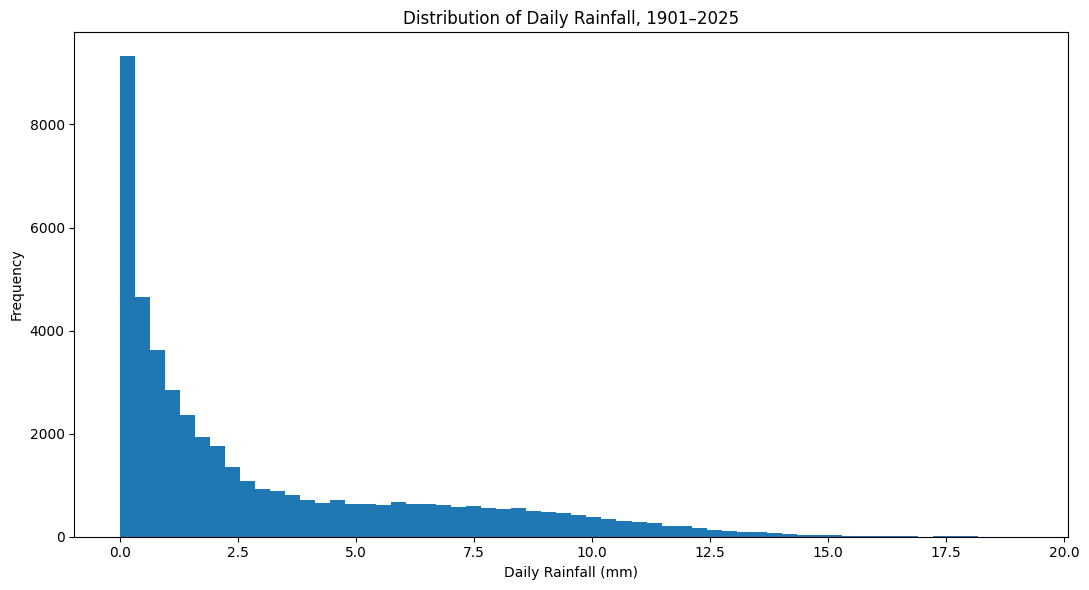

In [10]:
plt.figure(figsize=(11, 6))

plt.hist(
    master_df["Rainfall_mm"],
    bins=60
)

plt.xlabel("Daily Rainfall (mm)")
plt.ylabel("Frequency")
plt.title(
    "Distribution of Daily Rainfall, 1901–2025"
)

plt.tight_layout()
plt.show()

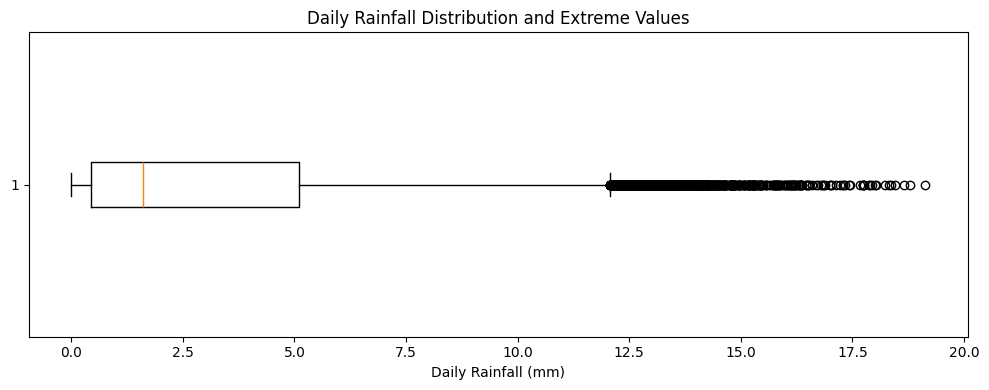

In [13]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    master_df["Rainfall_mm"],
    vert=False
)

plt.xlabel("Daily Rainfall (mm)")
plt.title(
    "Daily Rainfall Distribution and Extreme Values"
)

plt.tight_layout()
plt.show()

## Wet/dry day analysis

In [15]:
master_df["Wet_Day"] = (
    master_df["Rainfall_mm"] > 0
)

wet_days = master_df["Wet_Day"].sum()
dry_days = (~master_df["Wet_Day"]).sum()

wet_dry_summary = pd.DataFrame({
    "Category": ["Wet Days", "Dry Days"],
    "Days": [wet_days, dry_days],
    "Percentage": [
        wet_days / len(master_df) * 100,
        dry_days / len(master_df) * 100
    ]
})

wet_dry_summary["Percentage"] = (
    wet_dry_summary["Percentage"].round(2)
)

wet_dry_summary

,Category,Days,Percentage
0,Wet Days,44755,98.03
1,Dry Days,901,1.97


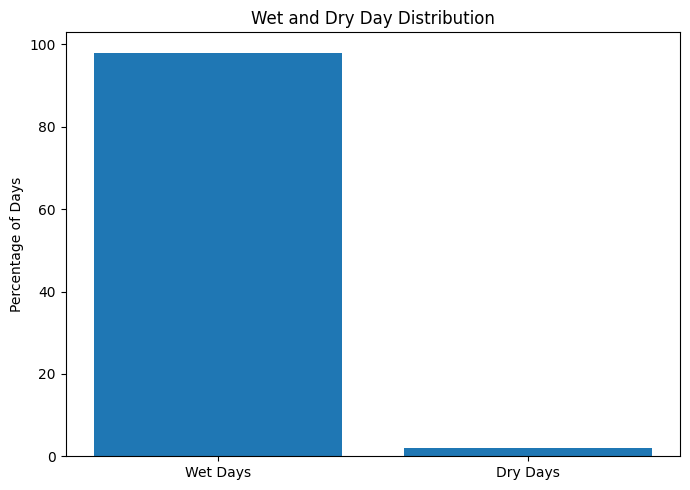

In [16]:
plt.figure(figsize=(7, 5))

plt.bar(
    wet_dry_summary["Category"],
    wet_dry_summary["Percentage"]
)

plt.ylabel("Percentage of Days")
plt.title("Wet and Dry Day Distribution")

plt.tight_layout()
plt.show()

## Annual Rainfall Analysis

In [17]:
annual_stats = (
    master_df
    .groupby("Year")["Rainfall_mm"]
    .agg(
        Total_Rainfall="sum",
        Mean_Daily_Rainfall="mean",
        Median_Daily_Rainfall="median",
        Std_Dev="std",
        Wet_Days=lambda x: (x > 0).sum(),
        Maximum_Daily_Rainfall="max"
    )
    .reset_index()
)

annual_stats.head()

,Year,Total_Rainfall,Mean_Daily_Rainfall,Median_Daily_Rainfall,Std_Dev,Wet_Days,Maximum_Daily_Rainfall
0,1901,1007.01,2.758932,1.510,3.057060,358,13.69
1,1902,1038.45,2.845068,1.570,3.260519,355,17.88
2,1903,1158.41,3.173726,1.550,3.552225,358,14.17
3,1904,1005.28,2.746667,1.415,3.075516,357,11.69
4,1905,963.72,2.640329,1.420,2.959383,358,13.71


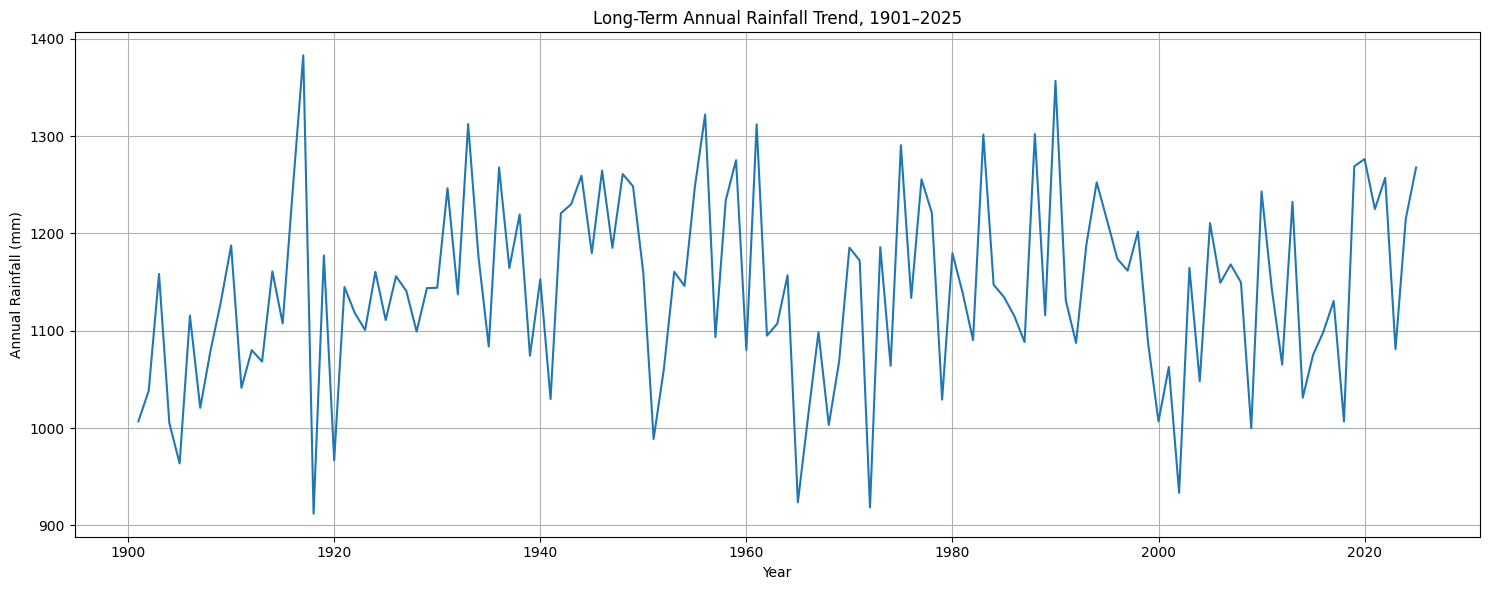

In [18]:
# Annual Rainfall Trend

plt.figure(figsize=(15, 6))

plt.plot(
    annual_stats["Year"],
    annual_stats["Total_Rainfall"]
)

plt.xlabel("Year")
plt.ylabel("Annual Rainfall (mm)")
plt.title(
    "Long-Term Annual Rainfall Trend, 1901–2025"
)

plt.grid(True)

plt.tight_layout()
plt.show()

### Solar Nakshatra Analysis

In [19]:
solar_nakshatra_stats = (
    master_df
    .groupby("solar_nakshatra")["Rainfall_mm"]
    .agg(
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Total="sum",
        Wet_Days=lambda x: (x > 0).sum(),
        Days="count"
    )
)

solar_nakshatra_stats = (
    solar_nakshatra_stats
    .sort_values("Mean", ascending=False)
)

solar_nakshatra_stats

,Mean,Median,Std_Dev,Total,Wet_Days,Days
solar_nakshatra,,,,,,
Pushya,9.297169,9.26,2.698201,16223.56,1745,1745
Punarvasu,9.076125,8.98,2.857255,15855.99,1747,1747
Ashlesha,8.441404,8.27,2.675993,14671.16,1738,1738
Ardra,7.631236,7.40,2.880909,13331.77,1747,1747
Magha,7.454719,7.38,2.419392,12889.21,1729,1729
Purva Phalguni,6.473762,6.36,2.467709,11115.45,1717,1717
Mrigashira,5.406980,5.08,2.546237,9435.18,1745,1745
Uttara Phalguni,5.210469,4.99,2.486484,8894.27,1707,1707
Hasta,3.515387,2.98,2.310976,5951.55,1693,1693


Ordered Nakshatra Visualization

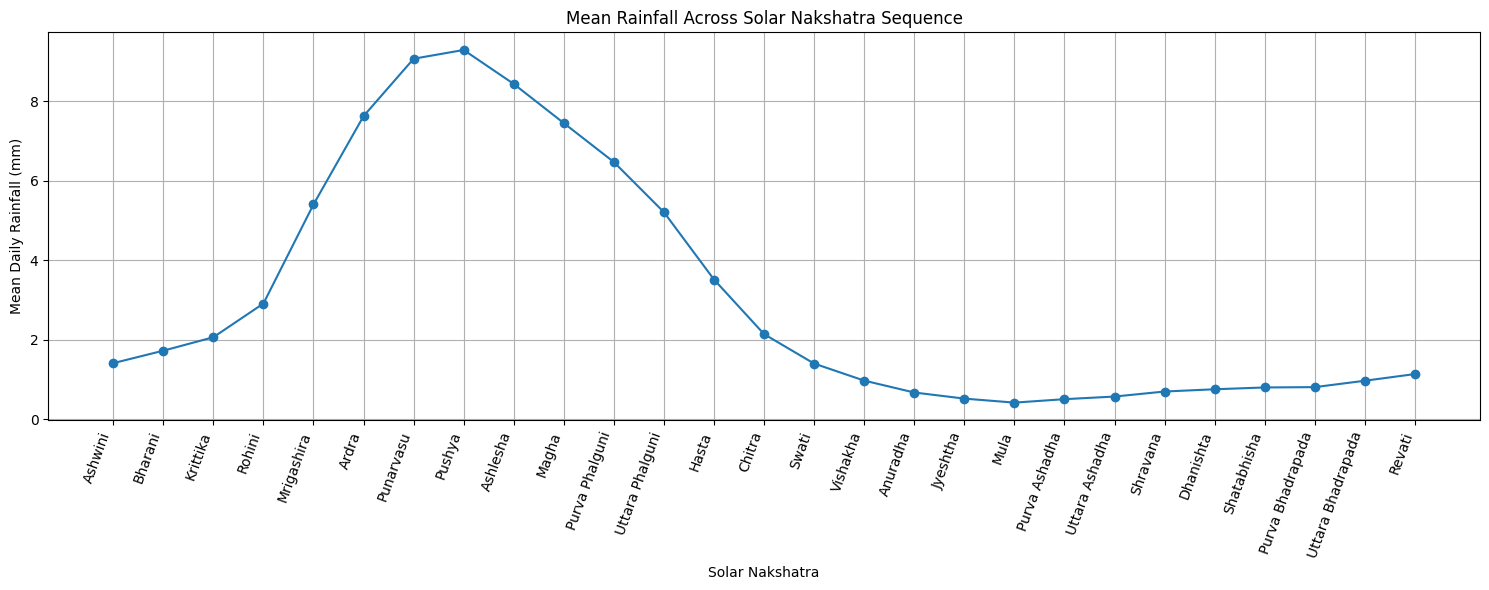

In [20]:
nakshatra_order = [
    "Ashwini", "Bharani", "Krittika", "Rohini",
    "Mrigashira", "Ardra", "Punarvasu", "Pushya",
    "Ashlesha", "Magha", "Purva Phalguni",
    "Uttara Phalguni", "Hasta", "Chitra", "Swati",
    "Vishakha", "Anuradha", "Jyeshtha", "Mula",
    "Purva Ashadha", "Uttara Ashadha", "Shravana",
    "Dhanishta", "Shatabhisha", "Purva Bhadrapada",
    "Uttara Bhadrapada", "Revati"
]

nakshatra_ordered = (
    master_df
    .groupby("solar_nakshatra")["Rainfall_mm"]
    .mean()
    .reindex(nakshatra_order)
)

plt.figure(figsize=(15, 6))

plt.plot(
    range(len(nakshatra_ordered)),
    nakshatra_ordered.values,
    marker="o"
)

plt.xlabel("Solar Nakshatra")
plt.ylabel("Mean Daily Rainfall (mm)")
plt.title(
    "Mean Rainfall Across Solar Nakshatra Sequence"
)

plt.xticks(
    range(len(nakshatra_order)),
    nakshatra_order,
    rotation=70,
    ha="right"
)

plt.grid(True)

plt.tight_layout()
plt.show()